# Entrenamiento de modelo

En este documento exploraremos diferentes modelos que demuestren su capacidad para la predicción de las 4 enfermedades:
- Anemia
- Diabetes
- Talasemia
- Trombocitopenia

y también identificar los casos de salud.

Modelos a demostrar:
- Árbol de decisiones
- Regresión lineal múltiple
- SVM
- Redes neuronales

> **Nota sobre balanceo:** El dataset original tiene Trombocitopenia con ~5% de las muestras frente al ~20% de las demás clases. Se aplica **SMOTE** al conjunto de entrenamiento para generar muestras sintéticas de la clase minoritaria. El conjunto de prueba **no se modifica** para que la evaluación refleje la realidad del dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.svm import SVC

import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importamos los datos
df = pd.read_csv('data/Blood_samples_dataset_balanced_2(f).csv')
print('Shape:', df.shape)
df.head()

Shape: (2351, 25)


,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse


In [3]:
# Variables óptimas y variable objetivo
features = [
    'Platelets',
    'White Blood Cells',
    'Red Blood Cells',
    'Hematocrit',
    'Mean Corpuscular Volume',
    'Mean Corpuscular Hemoglobin',
    'Mean Corpuscular Hemoglobin Concentration',
    'HDL Cholesterol',
    'ALT',
    'Heart Rate'
]

X = df[features]
y = df['Disease']

# Codificación de etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print('Clases:', class_names)
print('\nDistribución original:')
print(pd.Series(y).value_counts())

Clases: ['Anemia' 'Diabetes' 'Healthy' 'Thalasse' 'Thromboc']

Distribución original:
Disease
Anemia      623
Healthy     556
Diabetes    540
Thalasse    509
Thromboc    123
Name: count, dtype: int64


In [4]:
# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split estratificado — mantiene proporciones reales en test
X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print('Train size:', X_train.shape[0])
print('Test size: ', X_test.shape[0])
print('\nDistribución en train (antes de SMOTE):')
print(pd.Series(le.inverse_transform(y_train_enc)).value_counts())

Train size: 1880
Test size:  471

Distribución en train (antes de SMOTE):
Anemia      498
Healthy     445
Diabetes    432
Thalasse    407
Thromboc     98
Name: count, dtype: int64


Train size después de SMOTE: 2490

Distribución en train (después de SMOTE):
Diabetes    498
Anemia      498
Thalasse    498
Thromboc    498
Healthy     498
Name: count, dtype: int64


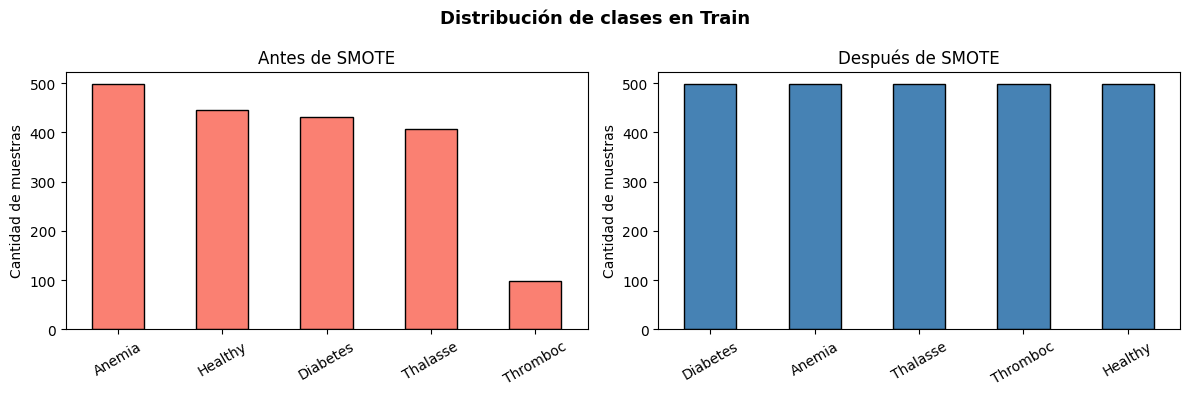

In [5]:
# Aplicamos SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train_enc)

print('Train size después de SMOTE:', X_train_bal.shape[0])
print('\nDistribución en train (después de SMOTE):')
print(pd.Series(le.inverse_transform(y_train_bal)).value_counts())

# Graficamos antes/después
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribución de clases en Train', fontsize=13, fontweight='bold')

before = pd.Series(le.inverse_transform(y_train_enc)).value_counts()
after  = pd.Series(le.inverse_transform(y_train_bal)).value_counts()

before.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Antes de SMOTE')
axes[0].set_ylabel('Cantidad de muestras')
axes[0].tick_params(axis='x', rotation=30)

after.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Después de SMOTE')
axes[1].set_ylabel('Cantidad de muestras')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('img/SMOTE_distribucion.png', dpi=120, bbox_inches='tight')
plt.show()

## Función auxiliar para graficar resultados

In [6]:
def plot_results(y_true, y_pred, model_name, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300) 
    fig.suptitle(f'Resultados: {model_name}', fontsize=14, fontweight='bold')

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Matriz de Confusión')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    axes[0].tick_params(axis='x', rotation=30)

    # Métricas por clase
    report = classification_report(y_true, y_pred, labels=class_names, output_dict=True)
    metrics_df = pd.DataFrame(report).T.loc[class_names, ['precision', 'recall', 'f1-score']]
    metrics_df.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='black')
    axes[1].set_title('Precisión, Recall y F1-Score por Clase')
    axes[1].set_ylim(0, 1.15)
    axes[1].set_xticklabels(class_names, rotation=30, ha='right')
    axes[1].legend(loc='lower right')
    axes[1].axhline(y=0.9, color='red', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(f'img/{model_name.replace(" ", "_")}_results.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'\nReporte de clasificación - {model_name}:')
    print(classification_report(y_true, y_pred, labels=class_names))

Varianza explicada por componente: [0.163 0.135 0.122]
Varianza total explicada: 0.420 (42.0%)



K-Means (k=5)
  Silhouette Score : 0.3296  (rango: -1 a 1; mayor es mejor)
  Adjusted Rand Index: 0.0873  (1 = clustering perfecto vs etiquetas reales)


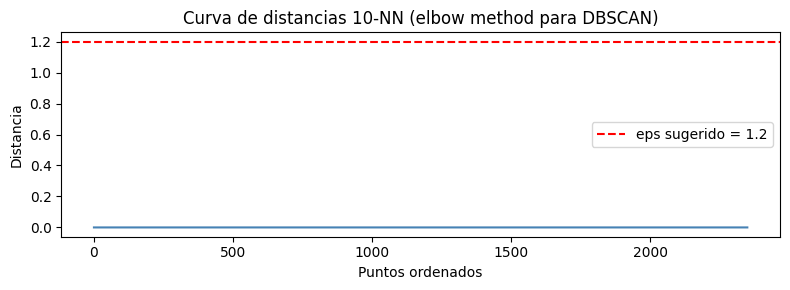


DBSCAN (eps=1.2, min_samples=10)
  Clusters encontrados : 9
  Puntos de ruido      : 0 (0.0%)
  Silhouette Score     : 0.0154
  Adjusted Rand Index  : -0.0011



COMPARATIVA: K-Means vs DBSCAN
Métrica                           K-Means       DBSCAN
-------------------------------------------------------
Clusters identificados                  5            9
Silhouette Score                   0.3296 0.015365043469483365
Adjusted Rand Index                0.0873 -0.0011237237994450211
Puntos de ruido (%)                     0         0.0%


In [7]:

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors

# ── Reducción a 3D con PCA ──────────────────────────────────
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)          # X_scaled ya existe del preprocesamiento

varianza = pca.explained_variance_ratio_
print(f"Varianza explicada por componente: {varianza.round(3)}")
print(f"Varianza total explicada: {varianza.sum():.3f} ({varianza.sum()*100:.1f}%)")

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['Disease'] = y.values          # etiquetas reales (solo para comparación visual)

# ── Figura 1: Distribución real de enfermedades en 3D ──────
colores_real = {
    'Anemia':    '#E74C3C',
    'Diabetes':  '#3498DB',
    'Healthy':   '#2ECC71',
    'Thalasse':  '#9B59B6',
    'Thromboc':  '#F39C12'
}

fig_real = go.Figure()
for clase, color in colores_real.items():
    mask = df_pca['Disease'] == clase
    fig_real.add_trace(go.Scatter3d(
        x=df_pca.loc[mask, 'PC1'],
        y=df_pca.loc[mask, 'PC2'],
        z=df_pca.loc[mask, 'PC3'],
        mode='markers',
        name=clase,
        marker=dict(size=3, color=color, opacity=0.7)
    ))

fig_real.update_layout(
    title=dict(text="Distribución real de enfermedades (PCA 3D)", font=dict(size=15)),
    scene=dict(
        xaxis_title=f'PC1 ({varianza[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({varianza[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({varianza[2]*100:.1f}%)',
        bgcolor='rgba(240,240,255,0.5)'
    ),
    legend_title="Enfermedad",
    width=800, height=600
)
fig_real.show()

# ── K-MEANS con k=5 ─────────────────────────────────────────
kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
labels_kmeans = kmeans.fit_predict(X_pca)

sil_km = silhouette_score(X_pca, labels_kmeans)
ari_km = adjusted_rand_score(y_encoded, labels_kmeans)
print(f"\nK-Means (k=5)")
print(f"  Silhouette Score : {sil_km:.4f}  (rango: -1 a 1; mayor es mejor)")
print(f"  Adjusted Rand Index: {ari_km:.4f}  (1 = clustering perfecto vs etiquetas reales)")

# Visualización 3D – K-Means
colores_km = px.colors.qualitative.Bold
centroides = kmeans.cluster_centers_

fig_km = go.Figure()
for c in range(5):
    mask = labels_kmeans == c
    fig_km.add_trace(go.Scatter3d(
        x=X_pca[mask, 0], y=X_pca[mask, 1], z=X_pca[mask, 2],
        mode='markers', name=f'Cluster {c+1}',
        marker=dict(size=3, color=colores_km[c], opacity=0.7)
    ))

# Añadir centroides
fig_km.add_trace(go.Scatter3d(
    x=centroides[:, 0], y=centroides[:, 1], z=centroides[:, 2],
    mode='markers', name='Centroides',
    marker=dict(size=8, symbol='cross', color='black',
                line=dict(color='white', width=1))
))

fig_km.update_layout(
    title=dict(text=f"K-Means Clustering (k=5) | Silhouette={sil_km:.3f} | ARI={ari_km:.3f}",
               font=dict(size=14)),
    scene=dict(
        xaxis_title=f'PC1 ({varianza[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({varianza[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({varianza[2]*100:.1f}%)',
        bgcolor='rgba(240,255,240,0.5)'
    ),
    legend_title="Cluster",
    width=800, height=600
)
fig_km.show()

# ── DBSCAN ──────────────────────────────────────────────────
# Estimación automática de eps con curva k-NN
k = 10
nbrs = NearestNeighbors(n_neighbors=k).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
knn_dist = np.sort(distances[:, k-1])[::-1]

import matplotlib.pyplot as plt
fig_eps, ax = plt.subplots(figsize=(8, 3))
ax.plot(knn_dist, color='steelblue')
ax.axhline(y=1.2, color='red', linestyle='--', label='eps sugerido = 1.2')
ax.set_title(f'Curva de distancias {k}-NN (elbow method para DBSCAN)')
ax.set_xlabel('Puntos ordenados'); ax.set_ylabel('Distancia')
ax.legend(); plt.tight_layout(); plt.show()

dbscan = DBSCAN(eps=1.2, min_samples=10)
labels_db = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = list(labels_db).count(-1)
pct_noise     = n_noise_db / len(labels_db) * 100

print(f"\nDBSCAN (eps=1.2, min_samples=10)")
print(f"  Clusters encontrados : {n_clusters_db}")
print(f"  Puntos de ruido      : {n_noise_db} ({pct_noise:.1f}%)")

if n_clusters_db > 1:
    mask_valid = labels_db != -1
    sil_db = silhouette_score(X_pca[mask_valid], labels_db[mask_valid])
    ari_db = adjusted_rand_score(y_encoded[mask_valid], labels_db[mask_valid])
    print(f"  Silhouette Score     : {sil_db:.4f}")
    print(f"  Adjusted Rand Index  : {ari_db:.4f}")

# Visualización 3D – DBSCAN
colores_db_map = {-1: 'lightgrey'}
unique_labels = sorted(set(labels_db))
palette = px.colors.qualitative.Vivid
for i, lbl in enumerate([l for l in unique_labels if l != -1]):
    colores_db_map[lbl] = palette[i % len(palette)]

fig_db = go.Figure()
for lbl in unique_labels:
    mask = labels_db == lbl
    nombre = f'Ruido ({n_noise_db} pts)' if lbl == -1 else f'Cluster {lbl+1}'
    fig_db.add_trace(go.Scatter3d(
        x=X_pca[mask, 0], y=X_pca[mask, 1], z=X_pca[mask, 2],
        mode='markers', name=nombre,
        marker=dict(
            size=2 if lbl == -1 else 4,
            color=colores_db_map[lbl],
            opacity=0.4 if lbl == -1 else 0.75
        )
    ))

fig_db.update_layout(
    title=dict(text=f"DBSCAN Clustering | {n_clusters_db} clusters | Ruido: {pct_noise:.1f}%",
               font=dict(size=14)),
    scene=dict(
        xaxis_title=f'PC1 ({varianza[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({varianza[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({varianza[2]*100:.1f}%)',
        bgcolor='rgba(255,245,240,0.5)'
    ),
    legend_title="Cluster",
    width=800, height=600
)
fig_db.show()

# ── Tabla comparativa de clusterización ─────────────────────
print("\n" + "="*55)
print("COMPARATIVA: K-Means vs DBSCAN")
print("="*55)
print(f"{'Métrica':<28} {'K-Means':>12} {'DBSCAN':>12}")
print("-"*55)
print(f"{'Clusters identificados':<28} {'5':>12} {str(n_clusters_db):>12}")
print(f"{'Silhouette Score':<28} {sil_km:>12.4f} {sil_db if n_clusters_db>1 else 'N/A':>12}")
print(f"{'Adjusted Rand Index':<28} {ari_km:>12.4f} {ari_db if n_clusters_db>1 else 'N/A':>12}")
print(f"{'Puntos de ruido (%)':<28} {'0':>12} {pct_noise:>11.1f}%")
print("="*55)

In [12]:
# Importamos para poder guardar los modelos entrenados
import joblib

## Modelo 1: Árbol de Decisión

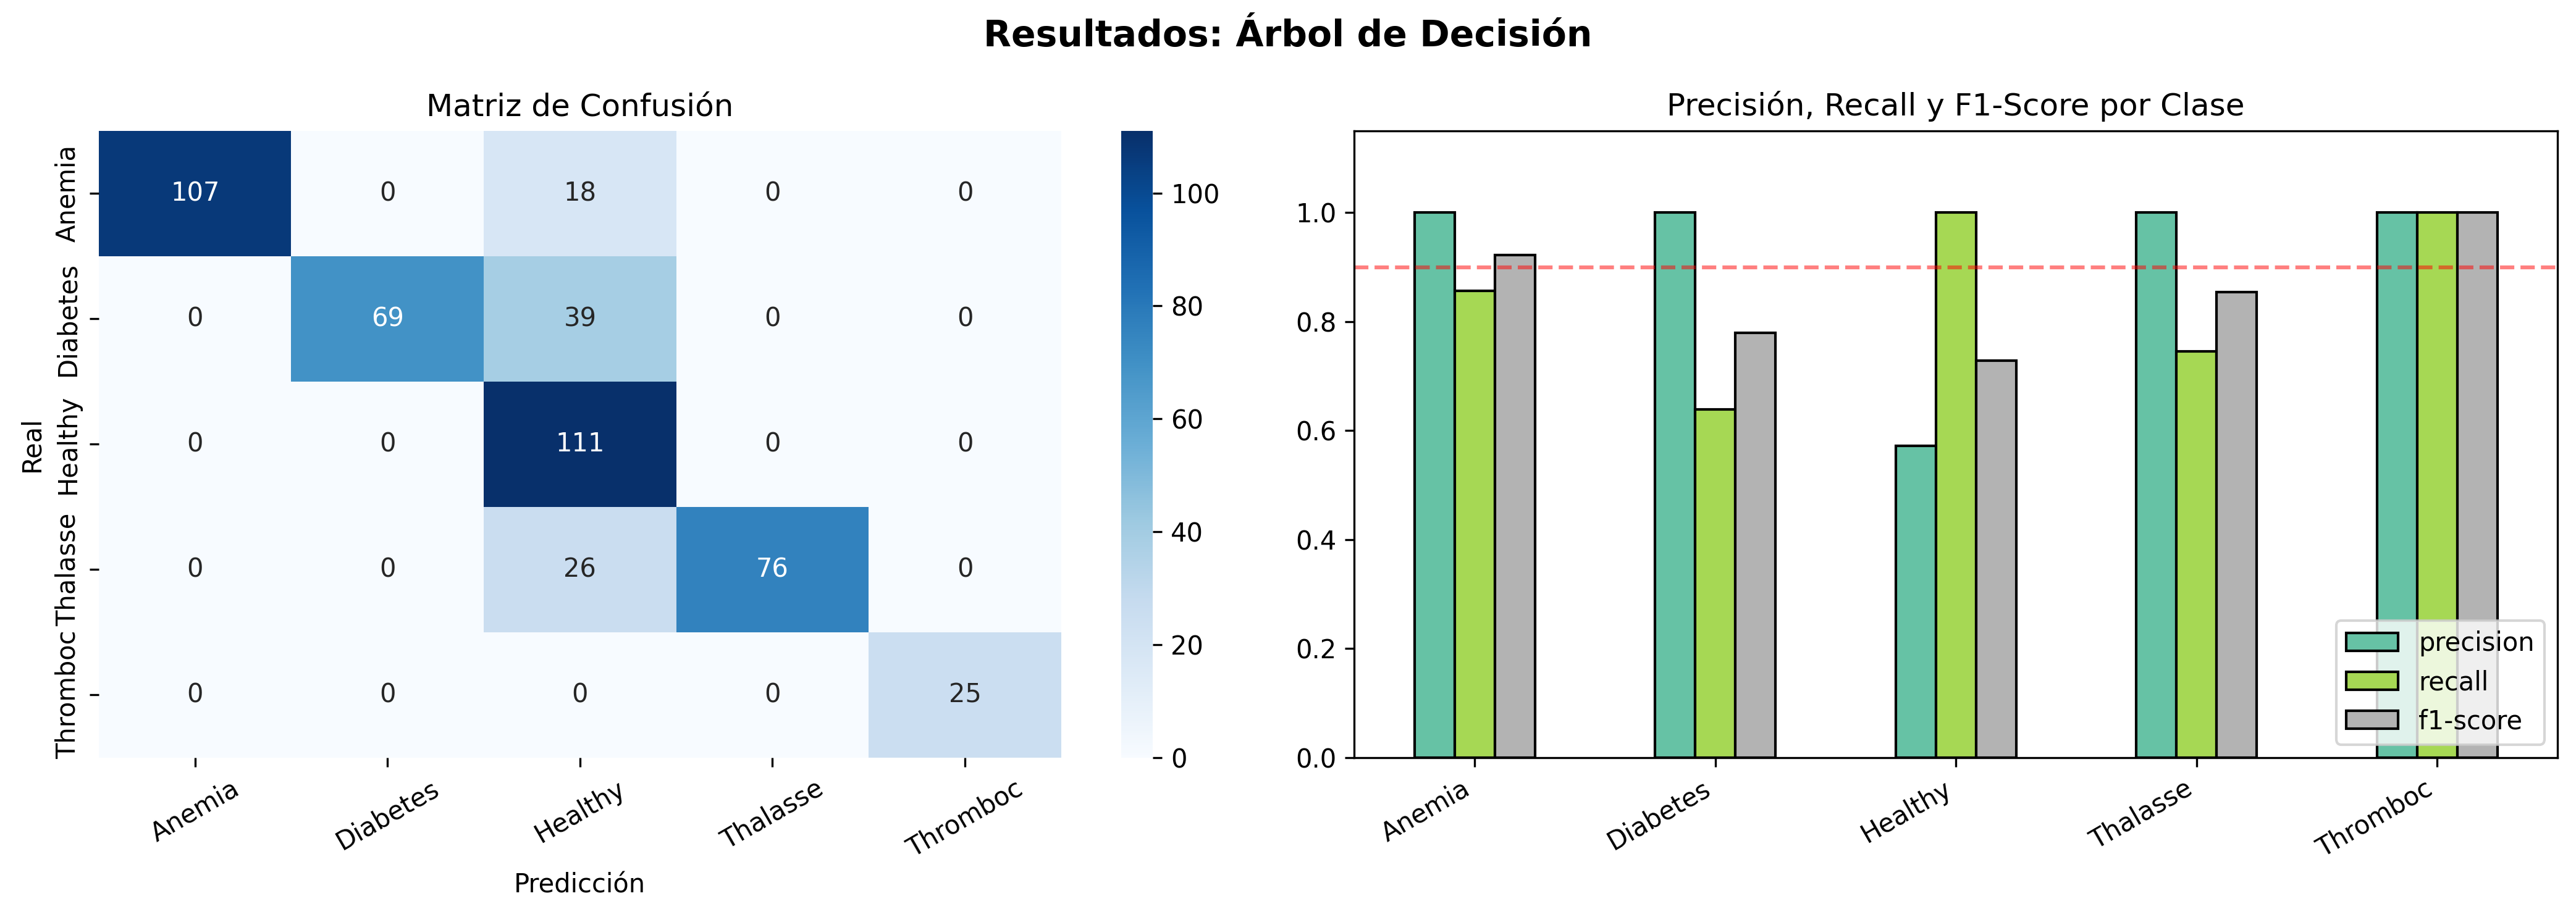


Reporte de clasificación - Árbol de Decisión:
              precision    recall  f1-score   support

      Anemia       1.00      0.86      0.92       125
    Diabetes       1.00      0.64      0.78       108
     Healthy       0.57      1.00      0.73       111
    Thalasse       1.00      0.75      0.85       102
    Thromboc       1.00      1.00      1.00        25

    accuracy                           0.82       471
   macro avg       0.91      0.85      0.86       471
weighted avg       0.90      0.82      0.83       471



['models/decision_tree_model.pkl']

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train_bal, y_train_bal)

y_pred_tree = le.inverse_transform(tree_model.predict(X_test))
y_test_str  = le.inverse_transform(y_test_enc)

plot_results(y_test_str, y_pred_tree, 'Árbol de Decisión', class_names)
# Guardamos el modelo de árbol de decisión para futuras predicciones

joblib.dump(tree_model, 'models_synthetics/decision_tree_model.pkl')


## Modelo 2: Regresión Lineal Múltiple

> **Nota:** La regresión lineal es un modelo para variables continuas. Se adapta para clasificación redondeando la predicción al índice de clase más cercano. Es una aproximación didáctica; para clasificación real se prefiere SVM o árboles.

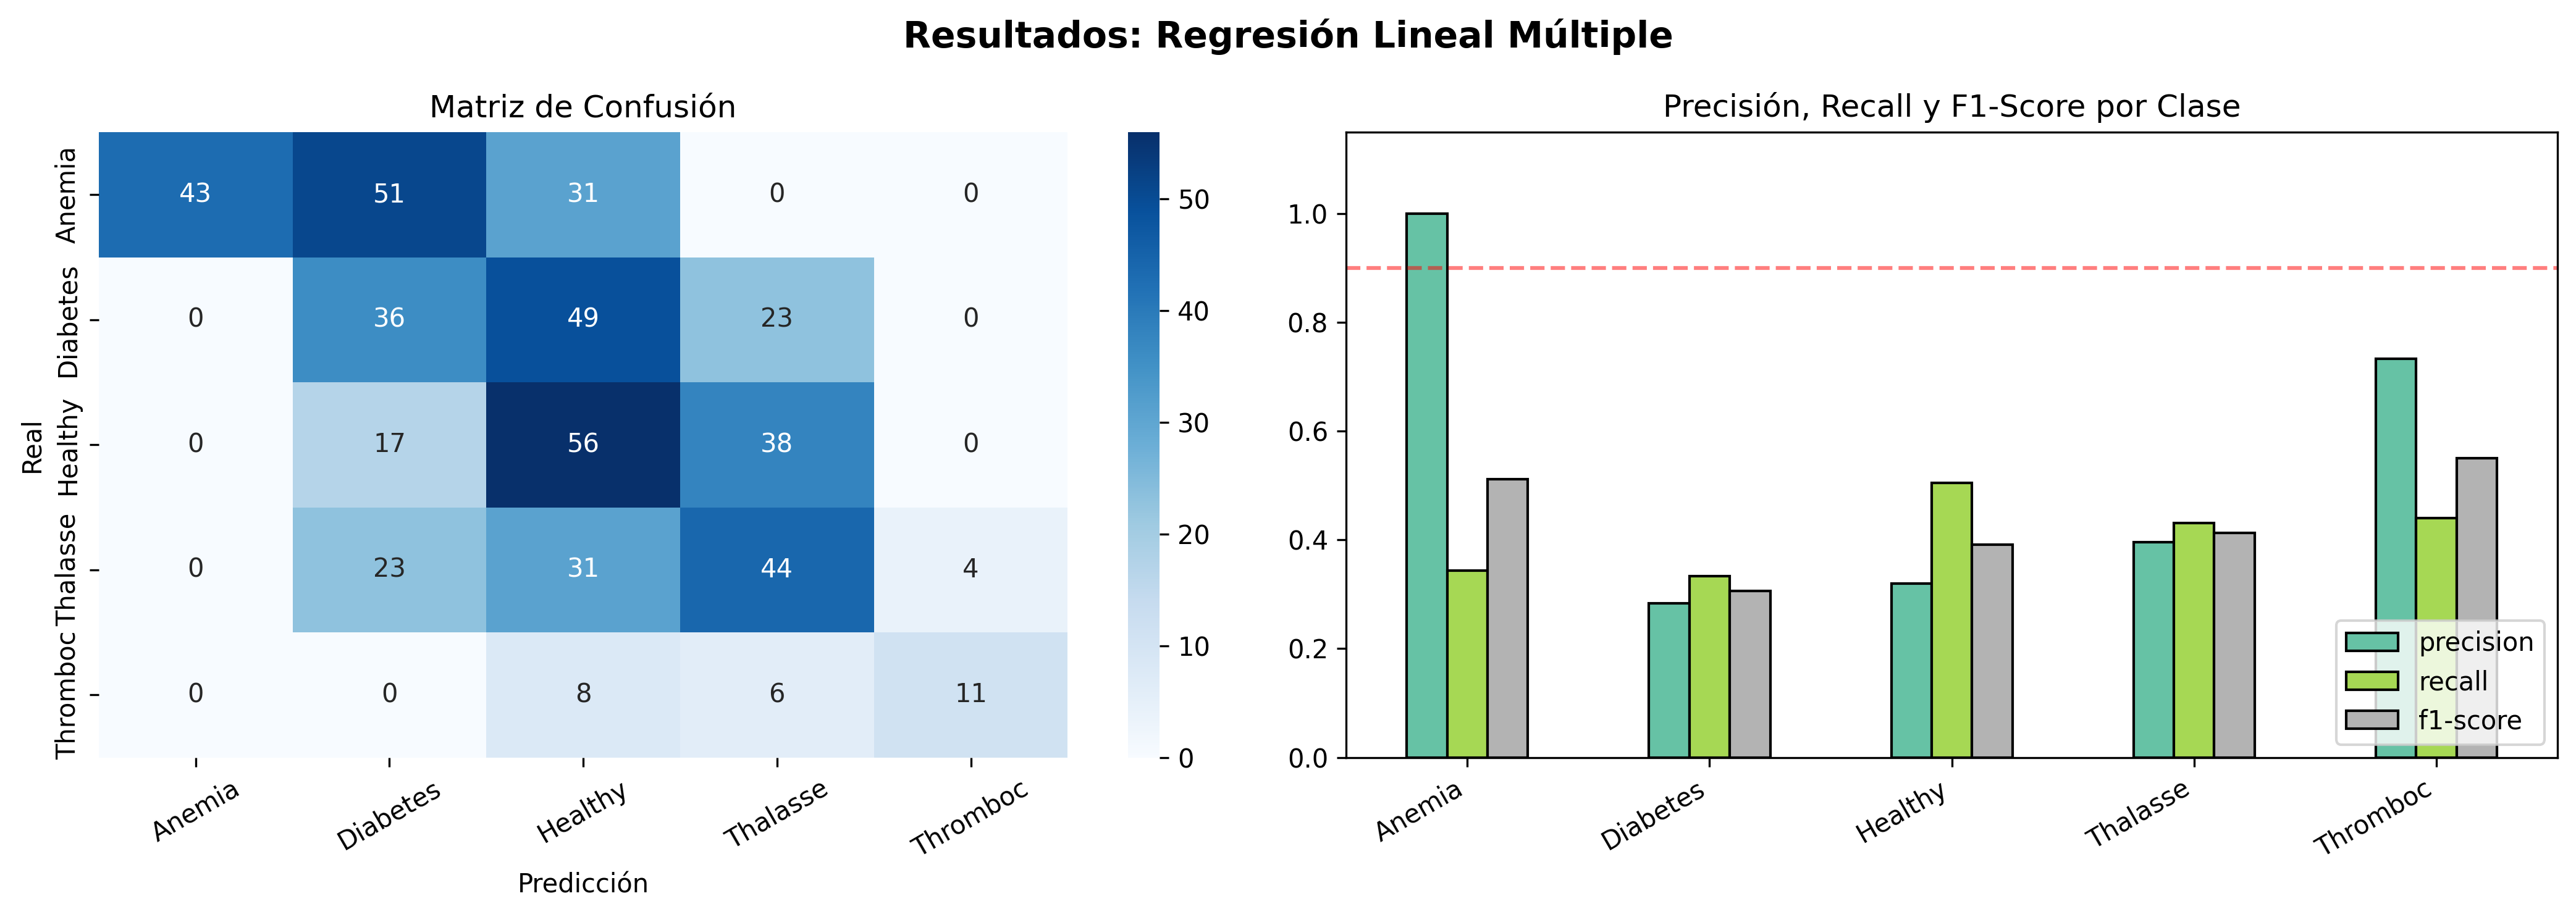


Reporte de clasificación - Regresión Lineal Múltiple:
              precision    recall  f1-score   support

      Anemia       1.00      0.34      0.51       125
    Diabetes       0.28      0.33      0.31       108
     Healthy       0.32      0.50      0.39       111
    Thalasse       0.40      0.43      0.41       102
    Thromboc       0.73      0.44      0.55        25

    accuracy                           0.40       471
   macro avg       0.55      0.41      0.43       471
weighted avg       0.53      0.40      0.42       471



In [9]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train_bal, y_train_bal)

y_pred_lin_raw = np.clip(np.round(lin_model.predict(X_test)).astype(int), 0, len(class_names) - 1)
y_pred_lin = le.inverse_transform(y_pred_lin_raw)

plot_results(y_test_str, y_pred_lin, 'Regresión Lineal Múltiple', class_names)

## Modelo 3: SVM (Support Vector Machine)

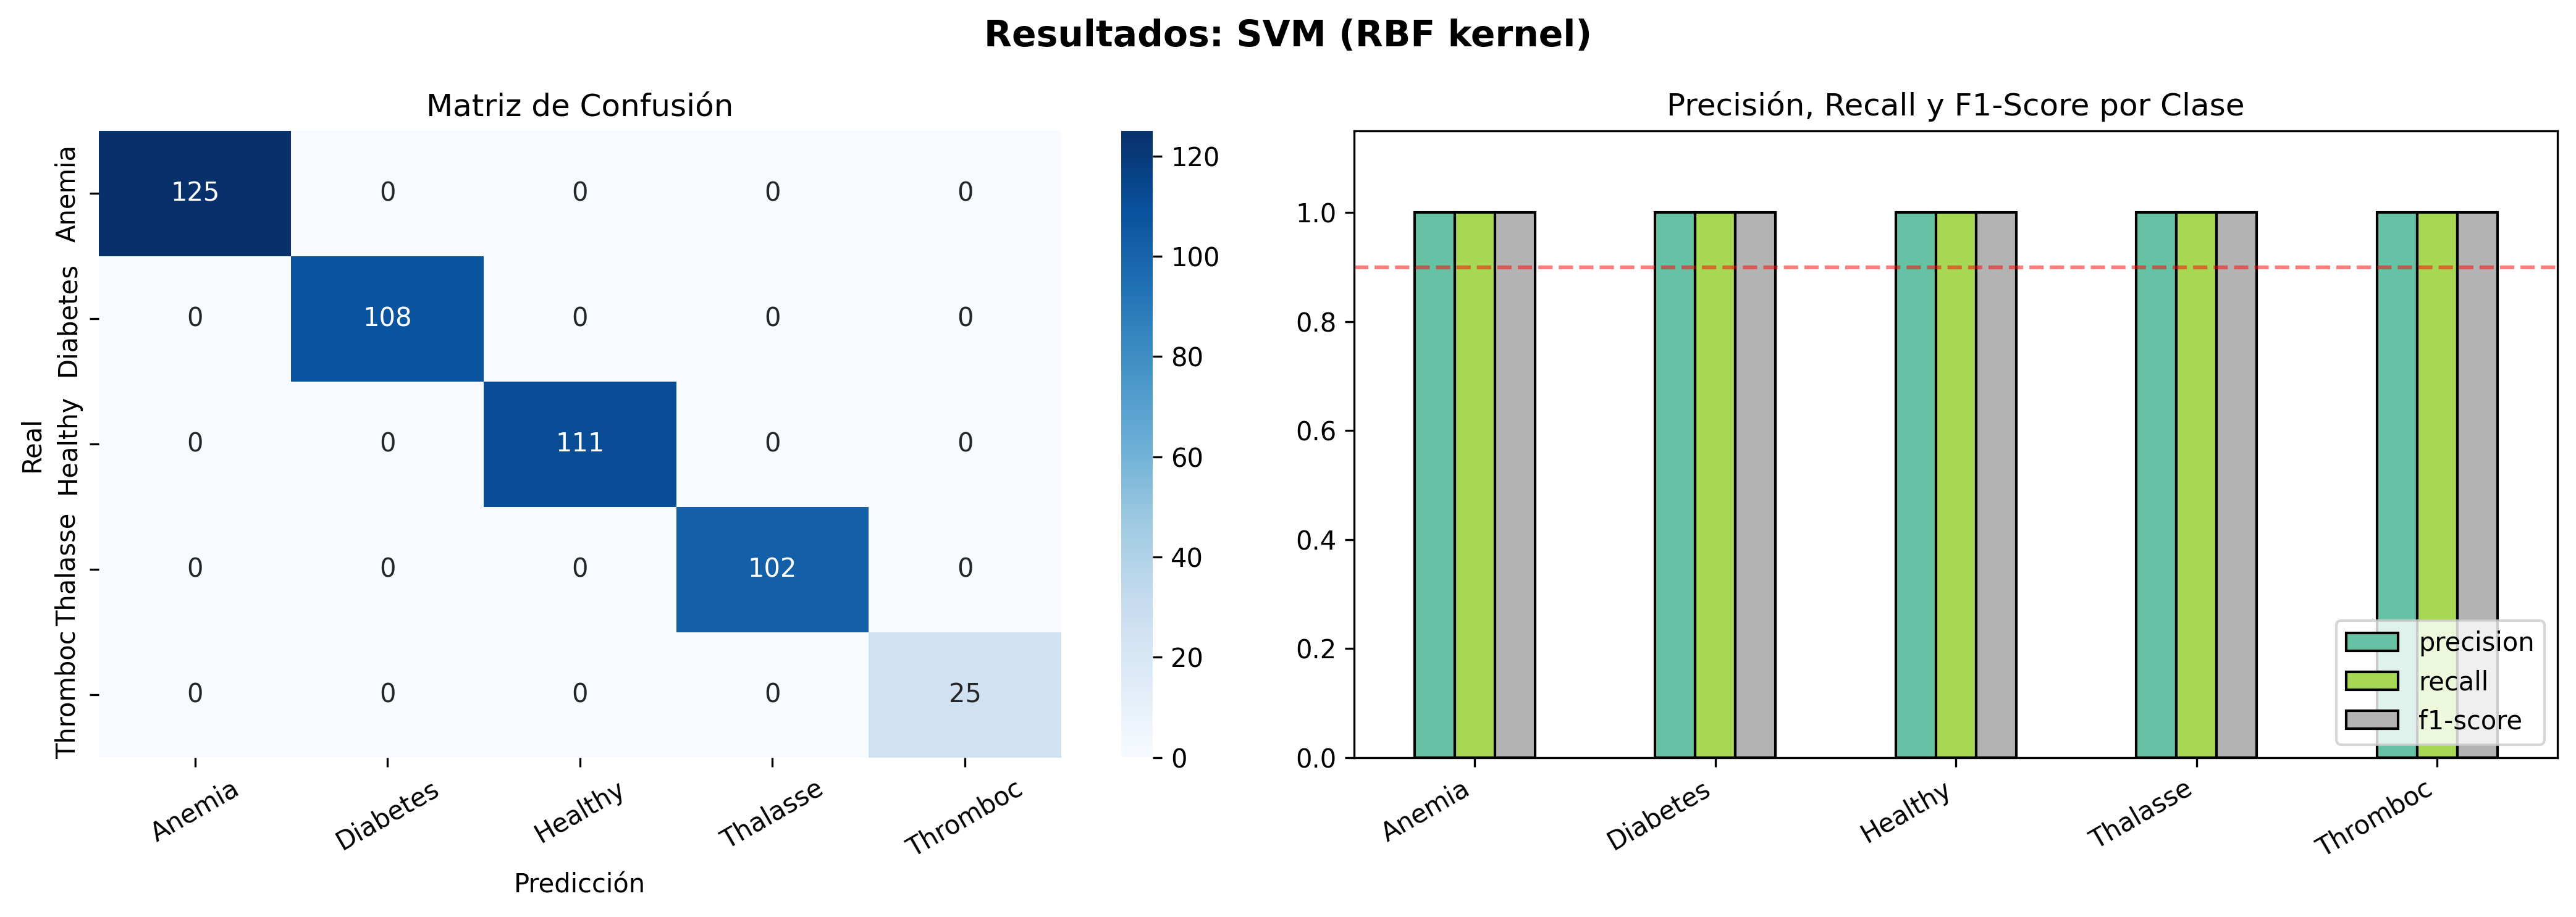


Reporte de clasificación - SVM (RBF kernel):
              precision    recall  f1-score   support

      Anemia       1.00      1.00      1.00       125
    Diabetes       1.00      1.00      1.00       108
     Healthy       1.00      1.00      1.00       111
    Thalasse       1.00      1.00      1.00       102
    Thromboc       1.00      1.00      1.00        25

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471



['models/svm_model.pkl']

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_model.fit(X_train_bal, y_train_bal)

y_pred_svm = le.inverse_transform(svm_model.predict(X_test))

plot_results(y_test_str, y_pred_svm, 'SVM (RBF kernel)', class_names)

joblib.dump(svm_model, 'models_synthetics/svm_model.pkl')

## Modelo 4: Red Neuronal (MLP)

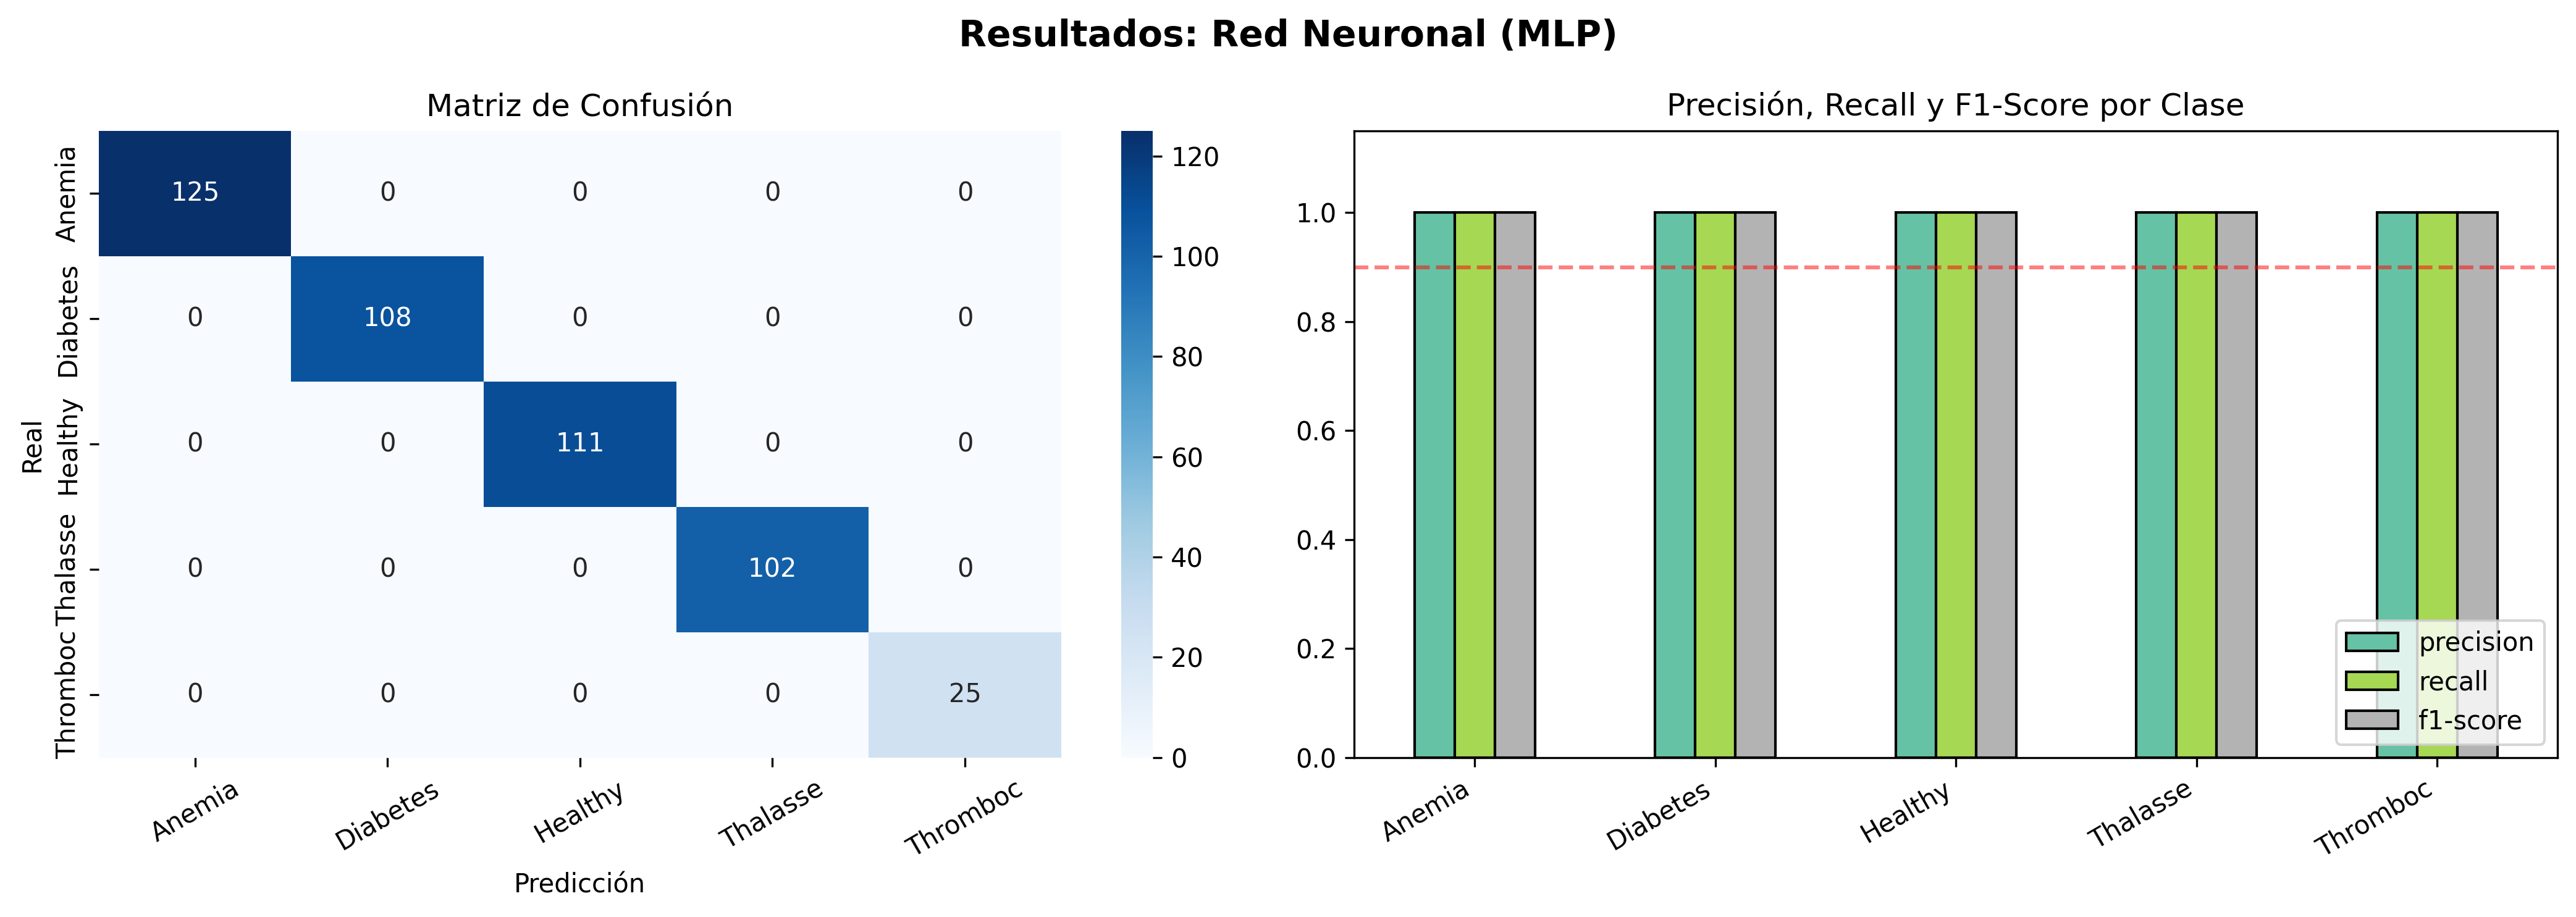


Reporte de clasificación - Red Neuronal (MLP):
              precision    recall  f1-score   support

      Anemia       1.00      1.00      1.00       125
    Diabetes       1.00      1.00      1.00       108
     Healthy       1.00      1.00      1.00       111
    Thalasse       1.00      1.00      1.00       102
    Thromboc       1.00      1.00      1.00        25

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471



['models/mlp_model.pkl']

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp_model.fit(X_train_bal, y_train_bal)

y_pred_mlp = le.inverse_transform(mlp_model.predict(X_test))

plot_results(y_test_str, y_pred_mlp, 'Red Neuronal (MLP)', class_names)

joblib.dump(mlp_model, 'models_synthetics/mlp_model.pkl')   # La red neuronal


## Comparación final de modelos

            Modelo  Accuracy  F1 Macro  F1 Weighted
 Árbol de Decisión  0.823779  0.856775     0.833120
  Regresión Lineal  0.403397  0.434608     0.417063
               SVM  1.000000  1.000000     1.000000
Red Neuronal (MLP)  1.000000  1.000000     1.000000


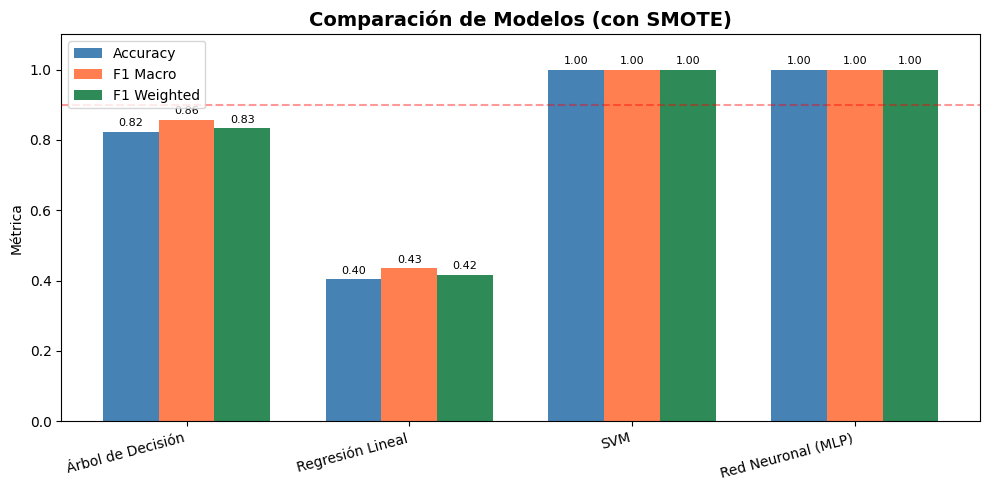

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

results = {
    'Árbol de Decisión':  (y_test_str, y_pred_tree),
    'Regresión Lineal':   (y_test_str, y_pred_lin),
    'SVM':                (y_test_str, y_pred_svm),
    'Red Neuronal (MLP)': (y_test_str, y_pred_mlp),
}

comparison = pd.DataFrame([
    {
        'Modelo':      name,
        'Accuracy':    accuracy_score(yt, yp),
        'F1 Macro':    f1_score(yt, yp, average='macro'),
        'F1 Weighted': f1_score(yt, yp, average='weighted')
    }
    for name, (yt, yp) in results.items()
])

print(comparison.to_string(index=False))

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
width = 0.25

bars1 = ax.bar(x - width, comparison['Accuracy'],     width, label='Accuracy',     color='steelblue')
bars2 = ax.bar(x,         comparison['F1 Macro'],     width, label='F1 Macro',     color='coral')
bars3 = ax.bar(x + width, comparison['F1 Weighted'],  width, label='F1 Weighted',  color='seagreen')

ax.set_title('Comparación de Modelos (con SMOTE)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Modelo'], rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Métrica')
ax.legend()
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4)

for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('img/Comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

  CROSS-VALIDATION — SVM y Red Neuronal MLP
  Estrategia: 10-Fold Stratified CV + SMOTE por fold

[SVM (RBF)] — entrenando 10 folds...
  Fold  1: Acc=1.0000  F1-Macro=1.0000  F1-Weighted=1.0000
  Fold  2: Acc=1.0000  F1-Macro=1.0000  F1-Weighted=1.0000
  Fold  3: Acc=1.0000  F1-Macro=1.0000  F1-Weighted=1.0000
  Fold  4: Acc=1.0000  F1-Macro=1.0000  F1-Weighted=1.0000
  Fold  5: Acc=1.0000  F1-Macro=1.0000  F1-Weighted=1.0000
  Fold  6: Acc=1.0000  F1-Macro=1.0000  F1-Weighted=1.0000
  Fold  7: Acc=1.0000  F1-Macro=1.0000  F1-Weighted=1.0000
  Fold  8: Acc=1.0000  F1-Macro=1.0000  F1-Weighted=1.0000
  Fold  9: Acc=1.0000  F1-Macro=1.0000  F1-Weighted=1.0000
  Fold 10: Acc=1.0000  F1-Macro=1.0000  F1-Weighted=1.0000

  ┌─────────────────────────────────────────────────┐
  │  Resumen 10-Fold CV — SVM (RBF)             │
  ├─────────────────────────────────────────────────┤
  │  Accuracy   │ Media: 1.0000 │ Std: 0.0000  │
  │  F1 Macro   │ Media: 1.0000 │ Std: 0.0000  │
  │  F1 Weighted│ 

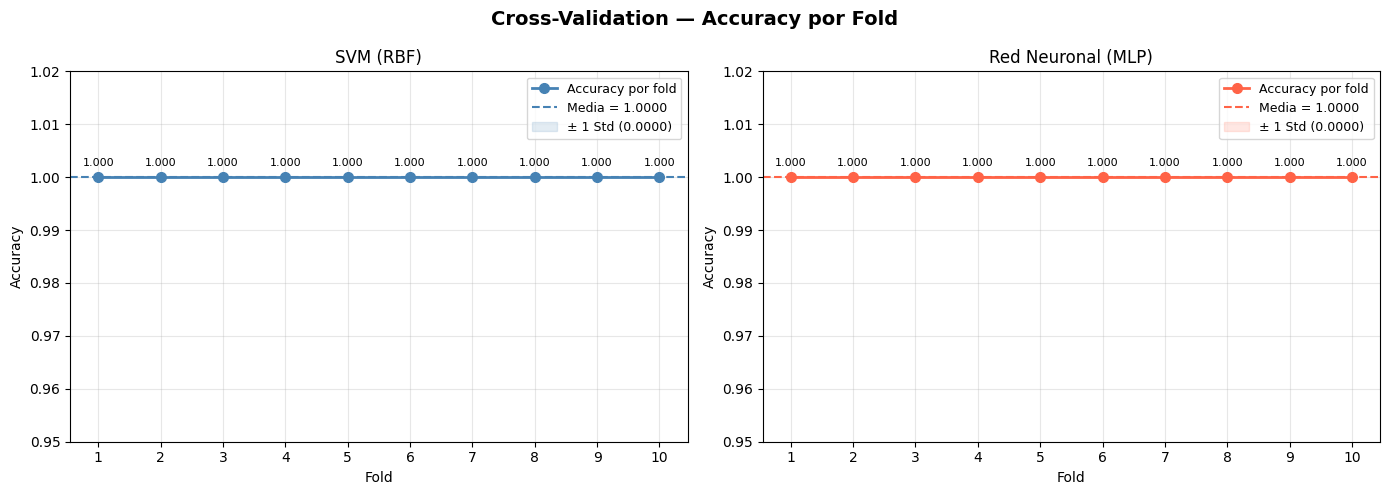

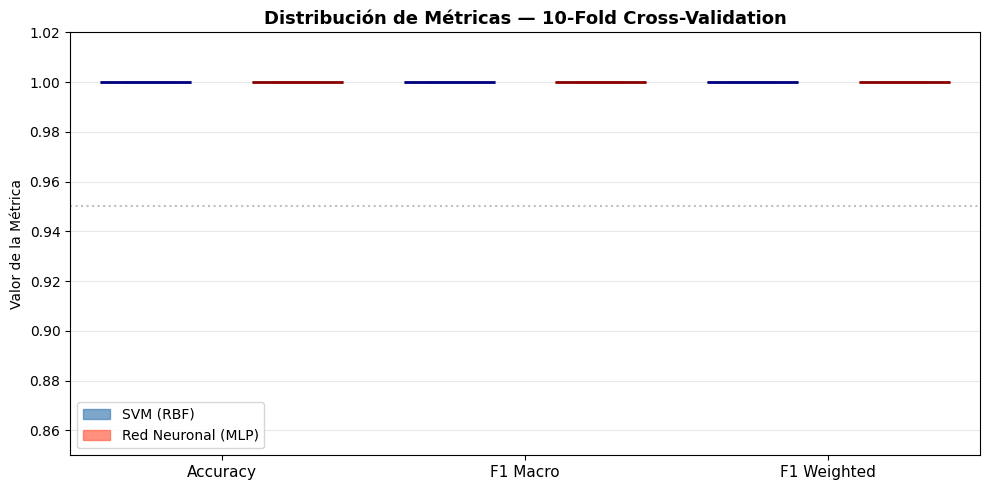

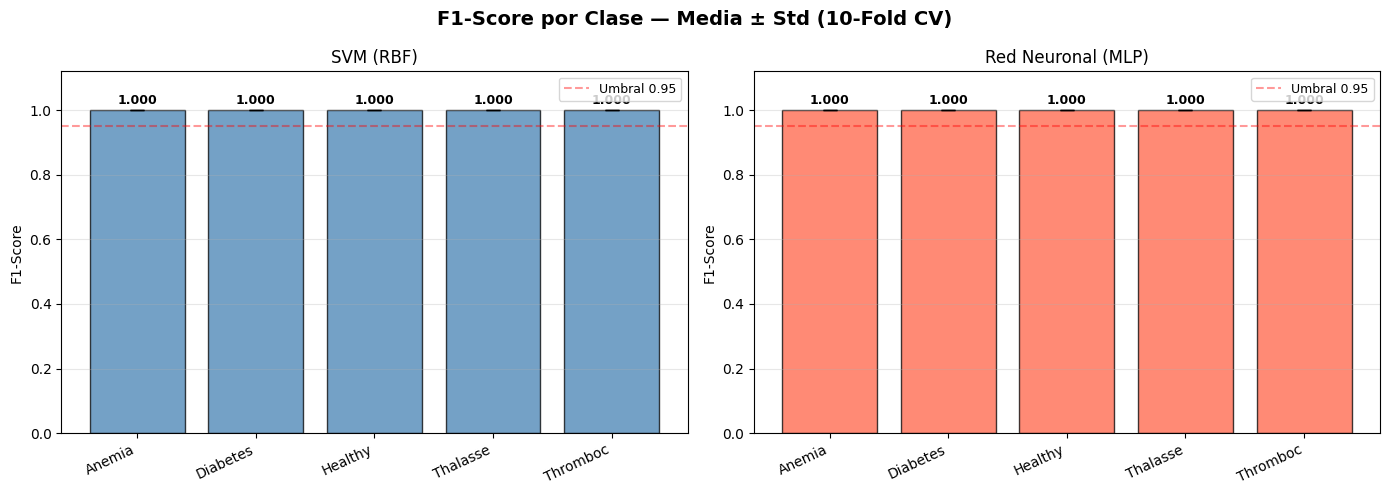

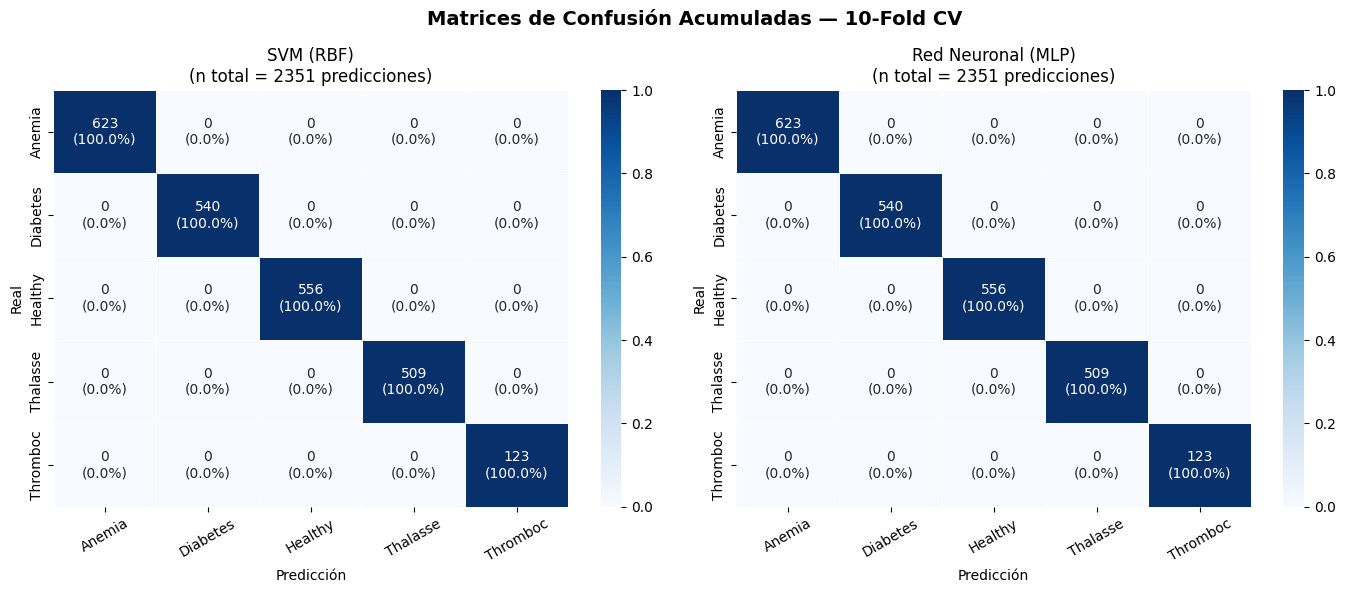


  TABLA RESUMEN — 10-Fold Stratified Cross-Validation
Modelo                  Acc Media   Acc Std  F1-Mac Med  F1-Mac Std         IC 95% Acc
--------------------------------------------------------------------
SVM (RBF)                  1.0000    0.0000      1.0000      0.0000   [1.0000, 1.0000]
Red Neuronal (MLP)         1.0000    0.0000      1.0000      0.0000   [1.0000, 1.0000]

✓ Validación completada.
  Un Std bajo (< 0.01) confirma estabilidad del modelo.
  Si Media ≥ 0.99 y Std ≤ 0.005 → el 100% es genuino.


In [ ]:
# ============================================================
# SECCIÓN 4.4 – VALIDACIÓN CRUZADA (CROSS-VALIDATION)
# SVM y Red Neuronal MLP — Modelos con 100% en test simple
# ============================================================
#
# PROPÓSITO: Verificar que el 100% de accuracy NO es producto
# de overfitting o data leakage, sino un resultado genuino.
#
# ESTRATEGIA: Pipeline completo que aplica SMOTE dentro de
# cada fold el conjunto de prueba de cada fold NUNCA ve
# datos sintéticos. Esto es la forma correcta de validar.
# ============================================================


# ── Configuración general ────────────────────────────────────
N_SPLITS   = 10          # 10-fold stratified cross-validation
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=" * 60)
print("  CROSS-VALIDATION — SVM y Red Neuronal MLP")
print(f"  Estrategia: {N_SPLITS}-Fold Stratified CV + SMOTE por fold")
print("=" * 60)

# ── Definición de modelos como Pipelines ────────────────────
# CRÍTICO: SMOTE + Scaler dentro del pipeline para evitar
# data leakage entre folds de entrenamiento y prueba.

models = {
    'SVM (RBF)': ImbPipeline([
        ('smote',   SMOTE(random_state=RANDOM_STATE)),
        ('scaler',  StandardScaler()),
        ('clf',     SVC(kernel='rbf', C=10, gamma='scale',
                        random_state=RANDOM_STATE, probability=True))
    ]),
    'Red Neuronal (MLP)': ImbPipeline([
        ('smote',   SMOTE(random_state=RANDOM_STATE)),
        ('scaler',  StandardScaler()),
        ('clf',     MLPClassifier(
            hidden_layer_sizes=(128, 64, 32),
            activation='relu', solver='adam',
            max_iter=500, random_state=RANDOM_STATE,
            early_stopping=True, validation_fraction=0.1
        ))
    ]),
}

# ── Cross-Validation principal ───────────────────────────────
skf    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True,
                         random_state=RANDOM_STATE)

cv_results = {}   # almacena métricas por fold
cv_reports = {}   # almacena classification reports

for model_name, pipeline in models.items():
    print(f"\n[{model_name}] — entrenando {N_SPLITS} folds...")
    
    fold_metrics = {
        'accuracy': [], 'f1_macro': [], 'f1_weighted': [],
        'f1_per_class': {cls: [] for cls in class_names}
    }
    all_y_true = []
    all_y_pred = []
    
    for fold, (train_idx, test_idx) in enumerate(
            skf.split(X, y_encoded), start=1):
        
        X_tr, X_te = X.values[train_idx], X.values[test_idx]
        y_tr, y_te = y_encoded[train_idx], y_encoded[test_idx]
        
        # Entrenar pipeline (SMOTE solo sobre X_tr)
        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_te)
        
        # Convertir a nombres de clase
        y_te_str   = le.inverse_transform(y_te)
        y_pred_str = le.inverse_transform(y_pred)
        
        # Acumular para matriz de confusión global
        all_y_true.extend(y_te_str)
        all_y_pred.extend(y_pred_str)
        
        # Métricas del fold
        acc  = accuracy_score(y_te_str, y_pred_str)
        f1m  = f1_score(y_te_str, y_pred_str, average='macro')
        f1w  = f1_score(y_te_str, y_pred_str, average='weighted')
        fold_metrics['accuracy'].append(acc)
        fold_metrics['f1_macro'].append(f1m)
        fold_metrics['f1_weighted'].append(f1w)
        
        rep = classification_report(
            y_te_str, y_pred_str, labels=class_names, output_dict=True)
        for cls in class_names:
            fold_metrics['f1_per_class'][cls].append(
                rep[cls]['f1-score'])
        
        print(f"  Fold {fold:>2}: Acc={acc:.4f}  F1-Macro={f1m:.4f}  F1-Weighted={f1w:.4f}")
    
    cv_results[model_name] = fold_metrics
    cv_reports[model_name] = {
        'y_true': all_y_true,
        'y_pred': all_y_pred
    }
    
    # ── Resumen estadístico ──────────────────────────────────
    acc_arr = np.array(fold_metrics['accuracy'])
    f1m_arr = np.array(fold_metrics['f1_macro'])
    f1w_arr = np.array(fold_metrics['f1_weighted'])
    
    print(f"\n  ┌─────────────────────────────────────────────────┐")
    print(f"  │  Resumen {N_SPLITS}-Fold CV — {model_name:<22}│")
    print(f"  ├─────────────────────────────────────────────────┤")
    print(f"  │  Accuracy   │ Media: {acc_arr.mean():.4f} │ Std: {acc_arr.std():.4f}  │")
    print(f"  │  F1 Macro   │ Media: {f1m_arr.mean():.4f} │ Std: {f1m_arr.std():.4f}  │")
    print(f"  │  F1 Weighted│ Media: {f1w_arr.mean():.4f} │ Std: {f1w_arr.std():.4f}  │")
    print(f"  │  IC 95% Acc │ [{acc_arr.mean()-1.96*acc_arr.std():.4f}, {acc_arr.mean()+1.96*acc_arr.std():.4f}]        │")
    print(f"  └─────────────────────────────────────────────────┘")

# ── VISUALIZACIÓN 1: Accuracy por fold (líneas) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cross-Validation — Accuracy por Fold',
             fontsize=14, fontweight='bold')

colores = {'SVM (RBF)': 'steelblue', 'Red Neuronal (MLP)': 'tomato'}
folds = list(range(1, N_SPLITS + 1))

for ax, (model_name, metrics) in zip(axes, cv_results.items()):
    acc = metrics['accuracy']
    media = np.mean(acc)
    std   = np.std(acc)
    color = colores[model_name]
    
    ax.plot(folds, acc, 'o-', color=color, lw=2, markersize=7,
            label='Accuracy por fold')
    ax.axhline(media, color=color, linestyle='--', lw=1.5,
               label=f'Media = {media:.4f}')
    ax.fill_between(folds,
                    [media - std] * N_SPLITS,
                    [media + std] * N_SPLITS,
                    alpha=0.15, color=color, label=f'± 1 Std ({std:.4f})')
    ax.set_ylim(max(0, media - 0.05), 1.02)
    ax.set_xticks(folds)
    ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy')
    ax.set_title(model_name)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # Anotar valores
    for f, a in zip(folds, acc):
        ax.annotate(f'{a:.3f}', (f, a), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('img/cv_accuracy_por_fold.png', dpi=120, bbox_inches='tight')
plt.show()

# ── VISUALIZACIÓN 2: Boxplot de métricas ────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
metrics_names = ['accuracy', 'f1_macro', 'f1_weighted']
labels_box    = ['Accuracy', 'F1 Macro', 'F1 Weighted']
positions_svm = [1, 3, 5]
positions_mlp = [2, 4, 6]

for pos, metric in zip(positions_svm, metrics_names):
    ax.boxplot(cv_results['SVM (RBF)'][metric],
               positions=[pos], widths=0.6,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               medianprops=dict(color='navy', lw=2),
               whiskerprops=dict(color='steelblue'),
               capprops=dict(color='steelblue'),
               flierprops=dict(marker='o', color='steelblue', markersize=6))

for pos, metric in zip(positions_mlp, metrics_names):
    ax.boxplot(cv_results['Red Neuronal (MLP)'][metric],
               positions=[pos], widths=0.6,
               patch_artist=True,
               boxprops=dict(facecolor='tomato', alpha=0.7),
               medianprops=dict(color='darkred', lw=2),
               whiskerprops=dict(color='tomato'),
               capprops=dict(color='tomato'),
               flierprops=dict(marker='o', color='tomato', markersize=6))

ax.set_xticks([1.5, 3.5, 5.5])
ax.set_xticklabels(labels_box, fontsize=11)
ax.set_ylabel('Valor de la Métrica')
ax.set_title('Distribución de Métricas — 10-Fold Cross-Validation',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.85, 1.02)
ax.axhline(0.95, color='gray', linestyle=':', alpha=0.5, label='Umbral 0.95')
ax.grid(axis='y', alpha=0.3)
patch_svm = mpatches.Patch(color='steelblue', alpha=0.7, label='SVM (RBF)')
patch_mlp = mpatches.Patch(color='tomato',    alpha=0.7, label='Red Neuronal (MLP)')
ax.legend(handles=[patch_svm, patch_mlp], fontsize=10)

plt.tight_layout()
plt.savefig('img/cv_boxplot_metricas.png', dpi=120, bbox_inches='tight')
plt.show()

# ── VISUALIZACIÓN 3: F1 por clase (barras de error) ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('F1-Score por Clase — Media ± Std (10-Fold CV)',
             fontsize=14, fontweight='bold')

x = np.arange(len(class_names))
for ax, (model_name, metrics) in zip(axes, cv_results.items()):
    means = [np.mean(metrics['f1_per_class'][c]) for c in class_names]
    stds  = [np.std(metrics['f1_per_class'][c])  for c in class_names]
    color = colores[model_name]
    
    bars = ax.bar(x, means, yerr=stds, capsize=5,
                  color=color, alpha=0.75, edgecolor='black',
                  error_kw=dict(elinewidth=1.5, ecolor='black'))
    
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=25, ha='right')
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('F1-Score')
    ax.set_title(model_name)
    ax.axhline(0.95, color='red', linestyle='--', alpha=0.4, label='Umbral 0.95')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + s + 0.01,
                f'{m:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('img/cv_f1_por_clase.png', dpi=120, bbox_inches='tight')
plt.show()

# ── VISUALIZACIÓN 4: Matrices de confusión acumuladas ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Matrices de Confusión Acumuladas — 10-Fold CV',
             fontsize=14, fontweight='bold')

for ax, (model_name, data) in zip(axes, cv_reports.items()):
    cm = confusion_matrix(data['y_true'], data['y_pred'], labels=class_names)
    
    # Normalizar por fila (recall por clase)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    annot = np.array([[f'{v}\n({p:.1%})' 
                       for v, p in zip(row_c, row_p)]
                      for row_c, row_p in zip(cm, cm_norm)])
    
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1,
                linewidths=0.5, linecolor='white')
    ax.set_title(f'{model_name}\n(n total = {len(data["y_true"])} predicciones)')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('img/cv_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

# ── TABLA RESUMEN FINAL ──────────────────────────────────────
print("\n" + "=" * 68)
print("  TABLA RESUMEN — 10-Fold Stratified Cross-Validation")
print("=" * 68)
print(f"{'Modelo':<22} {'Acc Media':>10} {'Acc Std':>9} {'F1-Mac Med':>11} "
      f"{'F1-Mac Std':>11} {'IC 95% Acc':>18}")
print("-" * 68)

for model_name, metrics in cv_results.items():
    acc = np.array(metrics['accuracy'])
    f1m = np.array(metrics['f1_macro'])
    ic_lo = acc.mean() - 1.96 * acc.std()
    ic_hi = acc.mean() + 1.96 * acc.std()
    print(f"{model_name:<22} {acc.mean():>10.4f} {acc.std():>9.4f} "
          f"{f1m.mean():>11.4f} {f1m.std():>11.4f} "
          f"  [{ic_lo:.4f}, {ic_hi:.4f}]")

print("=" * 68)
print("\n✓ Validación completada.")
print("  Un Std bajo (< 0.01) confirma estabilidad del modelo.")
print("  Si Media ≥ 0.99 y Std ≤ 0.005 → el 100% es genuino.")